# 指纹图片分类

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from PIL import Image

## 1. 读取指纹数据

In [2]:
class FVC2002Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # 过滤出所有的 .tif 文件
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # 加载图像并转为灰度图（指纹图通常是单通道）
        image = Image.open(img_path).convert('L')
        
        # 解析标签：例如 "10_3.tif" -> 标签为 10
        # 注意：类别索引通常从 0 开始，所以我们将 ID 减 1
        label = int(img_name.split('_')[0]) - 1
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [3]:
# 临时加载数据集（仅 ToTensor）
dataset = FVC2002Dataset(root_dir='../FVC2002/Db1',
                        transform=transforms.Compose([
                        transforms.Grayscale(),
                        transforms.ToTensor()
                               ]))
loader = DataLoader(dataset, batch_size=100, shuffle=False)

def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0
    for images, _ in loader:
        image_count_in_batch = images.size(0)
        images = images.view(image_count_in_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += image_count_in_batch
    mean /= total_images_count
    std /= total_images_count
    return mean, std

mean, std = get_mean_and_std(loader)
print(f"Mean: {mean}, Std: {std}")

Mean: tensor([0.8499]), Std: tensor([0.2375])


In [4]:
from torch.utils.data import Dataset, DataLoader, random_split

class ApplyTransform(Dataset):
    """
    一个简单的装饰器类，用于给 Subset 应用特定的 transform
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. 定义两个不同的 Pipeline
# 基础操作（训练和测试共有）
base_ops = [
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.85], std=[0.2375])
]

# 训练集特有：加入随机旋转
train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    *base_ops
])

# 测试集：仅基础操作
test_transforms = transforms.Compose(base_ops)

# 2. 原始数据集加载时不带 transform (或者只带 Resize)
full_dataset = FVC2002Dataset(root_dir='../FVC2002/Db1', transform=None)

# 3. 拆分索引
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_subset, test_subset = random_split(full_dataset, [train_size, test_size])

# 4. 分别包装，应用不同的 transform
train_dataset = ApplyTransform(train_subset, transform=train_transforms)
test_dataset = ApplyTransform(test_subset, transform=test_transforms)

In [5]:
len(train_dataset), len(test_dataset)

(704, 176)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2. 构建模型

### 2.1 ResNet 18

In [9]:
# def get_model(num_classes=100):
#     # 加载(ImageNet)预训练的 ResNet18
#     model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
#     # 修改第一层：将 3 通道输入改为 1 通道
#     # 原始：nn.Conv2d(3, 64, kernel_size=7, ...)
#     model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    
#     # 修改全连接层：适配 100 类输出
#     num_ftrs = model.fc.in_features
#     model.fc = nn.Linear(num_ftrs, num_classes)
    
#     return model

### 2.1.1 调用官方预训练模型

In [7]:
def get_model(num_classes=110): # FVC2002 DB1 通常是 110 类
    # 1. 加载预训练模型
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # 2. 保存原始的 conv1 权重
    original_conv1 = model.conv1
    
    # 3. 创建新的单通道 conv1
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=3, bias=False)
    
    # 4. 【核心改进】将 3 通道权重合并到 1 通道，而不是随机初始化
    # 将 RGB 权重的均值赋给单通道
    with torch.no_grad():
        model.conv1.weight.data = original_conv1.weight.data.sum(dim=1, keepdim=True)
    
    # 5. 修改全连接层
    num_ftrs = model.fc.in_features
    
    # 针对小数据集，建议在 FC 层前加个 Dropout 防止过拟合
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model

### 2.1.2 源码级实现

In [ ]:
# 1. 定义基本的残差块 (Basic Block)
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        # 第二个卷积层
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # 快捷连接 (Shortcut/Skip Connection)
        # 如果步长不为1或输入输出通道不一致，需要用 1x1 卷积对齐维度
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # 核心：将输入 x 经过 shortcut 后直接加到输出上
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

# 2. 构建 ResNet 主体结构
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=110):
        super(ResNet, self).__init__()
        self.in_planes = 64

        # 输入预处理层：原本是 3 通道，我们改为 1 通道
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        # ResNet 的四个层级，每个层级包含若干个残差块
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        
        # 输出层
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# 3. 实例化标准的 ResNet18 (层配置为 [2, 2, 2, 2])
def resnet18(num_classes=110):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

### 2.2 Simple model

In [12]:
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

class TinyBlock(nn.Module):
    """精简版残差块"""
    def __init__(self, in_planes, planes, stride=1):
        super(TinyBlock, self).__init__()
        self.conv1 = conv3x3(in_planes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class TinyFingerResNet(nn.Module):
    def __init__(self, num_classes=110):
        super(TinyFingerResNet, self).__init__()
        self.in_planes = 32

        # 1. Stem层: 针对384x384输入，先进行一定的下采样
        # 384 -> 192
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 2. ResNet Stages
        # Stage 1: 192 -> 96
        self.layer1 = self._make_layer(32, stride=2)
        # Stage 2: 96 -> 48
        self.layer2 = self._make_layer(64, stride=2)
        # Stage 3: 48 -> 24
        self.layer3 = self._make_layer(128, stride=2)
        # Stage 4: 24 -> 12
        self.layer4 = self._make_layer(256, stride=2)

        # 3. 分类头
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5) # 增加Dropout防止过拟合
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, planes, stride):
        layers = []
        layers.append(TinyBlock(self.in_planes, planes, stride))
        self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

## 3. 模型训练

In [8]:
# 1. 训练一个 Epoch 的函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

In [9]:
# 2. 验证/测试函数 (基于你提供的 evaluate 修改)
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / len(loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [10]:
# 3. 总训练控制函数
def train(model, train_loader, test_loader, criterion, optimizer, device, epochs=20):
    # 用于记录历史数据以便绘图
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    print(f"开始训练，设备: {device}")
    for epoch in range(epochs):
        # 训练阶段
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        # 验证阶段
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        
        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{epochs} -> "
              f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}% | "
              f"Train Loss: {train_loss:.4f}")

    # 训练结束后进行可视化
    plot_history(history)
    return history

# 4. 可视化函数
def plot_history(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # 绘制损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### 3.1 ResNet18

### 3.1.1 预训练模型

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = get_model(num_classes=110).to(device)
optimizer = optim.Adam(model1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in model1.parameters())
print(f"总参数量: {total_params:,}")
history1 = train(model1, train_loader, test_loader, criterion, optimizer, device, epochs=20)

总参数量: 11,226,670
开始训练，设备: cuda


KeyboardInterrupt: 

### 3.1.2 自定义模型

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18_origin = resnet18(num_classes=110).to(device)
optimizer = optim.Adam(resnet18_origin.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in resnet18_origin.parameters())
print(f"总参数量: {total_params:,}")
history1 = train(resnet18_origin, train_loader, test_loader, criterion, optimizer, device, epochs=20)

总参数量: 11,224,110
开始训练，设备: cuda


### 3.2 Simple CNN

开始训练，设备: cuda
Epoch 1/50 -> Train Acc: 30.97%, Test Acc: 19.89% | Train Loss: 2.4603
Epoch 2/50 -> Train Acc: 42.61%, Test Acc: 25.57% | Train Loss: 2.1788
Epoch 3/50 -> Train Acc: 42.19%, Test Acc: 21.59% | Train Loss: 2.1221
Epoch 4/50 -> Train Acc: 48.58%, Test Acc: 28.41% | Train Loss: 1.9964
Epoch 5/50 -> Train Acc: 48.30%, Test Acc: 38.64% | Train Loss: 1.9267
Epoch 6/50 -> Train Acc: 51.99%, Test Acc: 32.95% | Train Loss: 1.7923
Epoch 7/50 -> Train Acc: 54.12%, Test Acc: 14.20% | Train Loss: 1.7083
Epoch 8/50 -> Train Acc: 55.54%, Test Acc: 27.27% | Train Loss: 1.6537
Epoch 9/50 -> Train Acc: 58.66%, Test Acc: 17.61% | Train Loss: 1.5728
Epoch 10/50 -> Train Acc: 61.65%, Test Acc: 42.61% | Train Loss: 1.5277
Epoch 11/50 -> Train Acc: 65.91%, Test Acc: 36.36% | Train Loss: 1.4548
Epoch 12/50 -> Train Acc: 66.48%, Test Acc: 45.45% | Train Loss: 1.3353
Epoch 13/50 -> Train Acc: 66.34%, Test Acc: 42.61% | Train Loss: 1.3161
Epoch 14/50 -> Train Acc: 68.32%, Test Acc: 37.50% | Train 

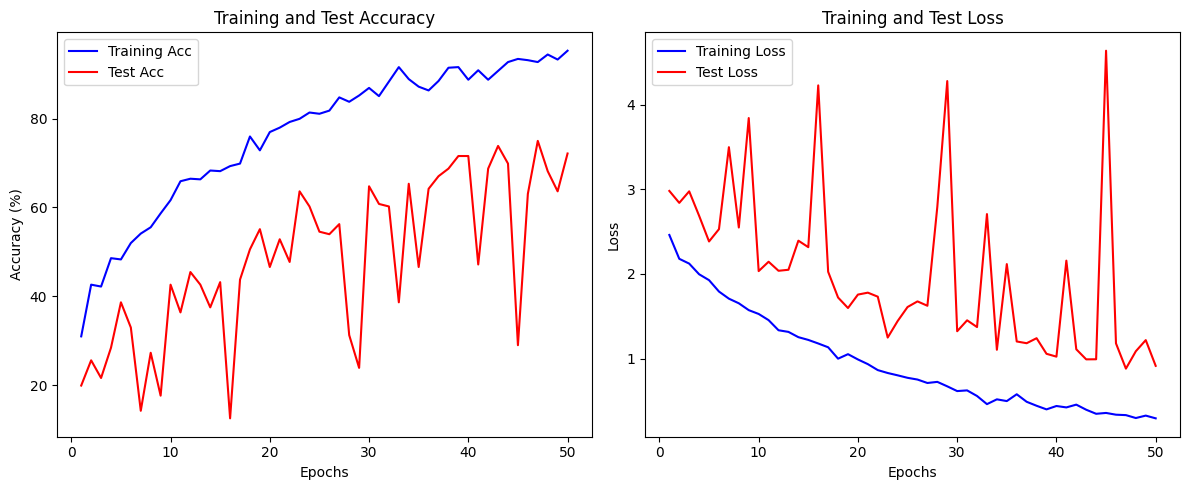

总参数量: 1,255,182


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = TinyFingerResNet(num_classes=110).to(device)
optimizer = optim.Adam(model2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
history1 = train(model2, train_loader, test_loader, criterion, optimizer, device, epochs=100)
total_params = sum(p.numel() for p in model2.parameters())
print(f"总参数量: {total_params:,}")